Setup

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load Dataset

In [4]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print('Feature matrix shape: ', X.shape)
print('Target Shape: ', y.shape)

Feature matrix shape:  (569, 30)
Target Shape:  (569,)


In [5]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

Train test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.25, random_state=42, stratify=y
)

print('Training samples: ', X_train.shape[0])
print('Test samples: ', X_test.shape[0])

Training samples:  426
Test samples:  143


Train A Baseline Random Forest model

In [7]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,  # n_estimators mane kotogula decision tree thakbe
    random_state=42
)

rf_baseline.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Make prediction

In [8]:
y_pred = rf_baseline.predict(X_test)

Model evaluation

In [9]:
acc = accuracy_score(y_test, y_pred)
print('Accuracy: ', acc)

Accuracy:  0.958041958041958


In [10]:
print('Classification Report:\n', classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



In [11]:
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)

Confusion Matrix:
 [[49  4]
 [ 2 88]]


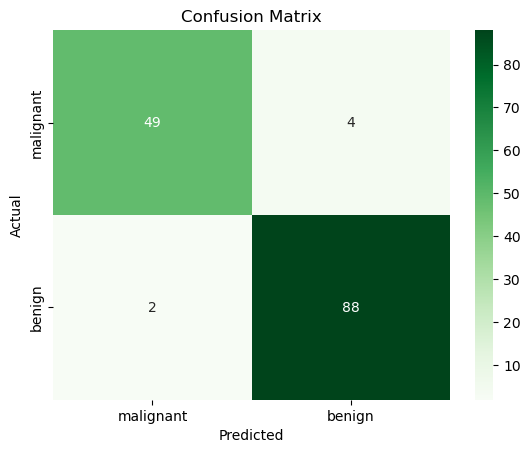

In [12]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Feature Importance

In [13]:
imp = pd.Series(
    rf_baseline.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

imp.head(10)

worst area              0.149674
worst concave points    0.127189
mean concave points     0.104650
worst radius            0.086963
worst perimeter         0.080299
mean perimeter          0.080037
mean concavity          0.055420
mean radius             0.053665
mean area               0.044062
area error              0.024557
dtype: float64

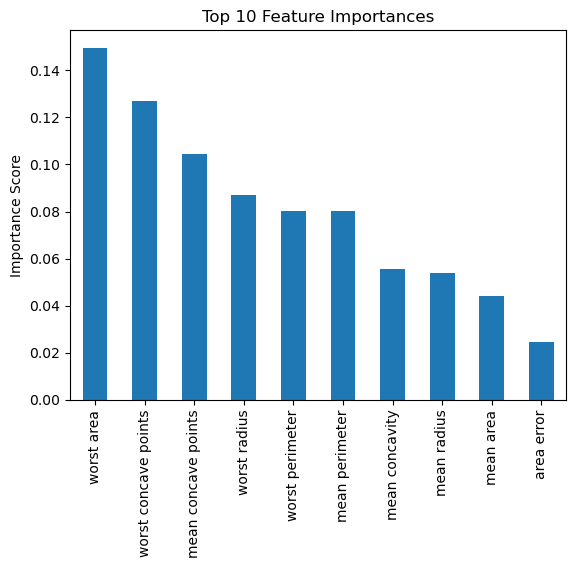

In [14]:
plt.figure()
imp.head(10).plot(kind='bar')
plt.title('Top 10 Feature Importances')
plt.ylabel('Importance Score')
plt.show()

Hyperparameter Tunig

In [17]:
# Key Hyperparameters
param_grid = {
    'n_estimators': [100, 150, 175, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2,3,5],
    'max_features': ['sqrt', 'log2']
}

In [18]:
# GridSearchCV
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv = 5,
    scoring='f1',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 3, 5],
                         'n_estimators': [100, 150, 175, 200]},
             scoring='f1')

In [19]:
print('Best Parameters: Found: \n', grid_rf.best_params_)

Best Parameters: Found: 
 {'max_depth': 5, 'max_features': 'log2', 'min_samples_split': 3, 'n_estimators': 100}


In [20]:
best_rf = grid_rf.best_estimator_
y_pred_best = best_rf.predict(X_test)

print('Accuracy: ', accuracy_score(y_test, y_pred_best))
print('Classification Report:\n', classification_report(y_test, y_pred_best))

Accuracy:  0.958041958041958
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143

